In [237]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import random
from zonolayer import fit_zonolayer, predict_zonolayer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from SLINN import SLINN, midrad

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

def check_collinearity(features, name="features"):
    n, d = features.shape
    print(f"--- Collinearity check for {name} (n={n}, d={d}) ---\n")

    # Correlation matrix
    corr = np.corrcoef(features, rowvar=False)
    print("Correlation matrix:")
    print(pd.DataFrame(corr, columns=[f"f{i}" for i in range(d)],
                        index=[f"f{i}" for i in range(d)]).round(3))
    print()
    cond = np.linalg.cond(features)
    print(f"Condition number (features only):        {cond:.2f}")

    # Eigenvalues of the correlation matrix (near-zero => collinear direction)
    eigvals = np.linalg.eigvalsh(corr)
    print("Eigenvalues of correlation matrix (ascending):")
    print(np.round(eigvals, 5))

    return {"corr": corr, "cond": cond, "eigvals": eigvals}

## Collinearity Experimentation

In [238]:
class RegressionNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=12):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.regressor = nn.Linear(hidden_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        
        if return_features:
            return out, features
        return out
    
class ZonoLayer(nn.Module):
    def __init__(self, hidden_dim=12, zono_dim=3):
        super().__init__()
        self.linear = nn.Linear(hidden_dim, zono_dim)

    def forward(self, features):
        return self.linear(features)
    

def train_centre(x_t, y_lb_t, y_ub_t, epochs=8000, lr=0.01, print_every=50):
    y_mid = (y_lb_t + y_ub_t) / 2

    centre_net = RegressionNetwork(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        pred = centre_net(x_t)
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")

    return centre_net

def train_zonolayer(centre_net, x_t, y_lb_t, y_ub_t, zono_dim=3, epochs=300, lr=1e-2, print_every=50):
    for p in centre_net.parameters():
        p.requires_grad = False
    centre_net.eval()

    with torch.no_grad():
        _, features = centre_net(x_t, return_features=True)

    hidden_dim = centre_net.regressor.in_features
    y_mid = (y_lb_t + y_ub_t) / 2

    zono_layer = ZonoLayer(hidden_dim=hidden_dim, zono_dim=zono_dim)

    with torch.no_grad():
        zono_layer.linear.weight[0:1, :] = centre_net.regressor.weight.data
        zono_layer.linear.bias[0:1]      = centre_net.regressor.bias.data

    optimizer = torch.optim.Adam(zono_layer.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        zono_layer.train()
        pred = zono_layer(features)[:, 0:1]
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"Zono epoch {epoch+1}: MSE = {loss.item():.6f}")

    return zono_layer

In [239]:
df = pd.read_csv("Data/input_data.txt", sep="\t", header=None, names=["x", "y_lower", "y_upper"])
x = df["x"].to_numpy().reshape(-1, 1)
y_lower = df["y_lower"].to_numpy().reshape(-1, 1)
y_upper = df["y_upper"].to_numpy().reshape(-1, 1)

x_t = torch.tensor(x, dtype=torch.float32)
y_lb_t = torch.tensor(y_lower, dtype=torch.float32)
y_ub_t = torch.tensor(y_upper, dtype=torch.float32)
x_grid = np.linspace(0, 1, 200).reshape(-1, 1)


def extract_zono_predictions(centre_net, zono_layer, x):
    centre_net.eval()
    zono_layer.eval()
    with torch.no_grad():
        pred, c_features = centre_net(x, return_features=True)
        features = zono_layer(c_features)
    return pred.numpy(), features.numpy()

def run_zonolayer_experiment(centre_net, x_train, y_lb_train, y_ub_train, x_test, zono_dim):
    # Train zonolayer
    zono_layer = train_zonolayer(centre_net, x_train, y_lb_train, y_ub_train, zono_dim=zono_dim)

    # Extract latent representations
    pred_train, latent_train = extract_zono_predictions(centre_net, zono_layer, x_train)
    pred_test, latent_test = extract_zono_predictions(centre_net, zono_layer, x_test)

    # Fit zonotope predictor
    zonolayer_fit = fit_zonolayer(latent_train, y_lower, y_upper)
    zonolayer = predict_zonolayer(zonolayer_fit, latent_test)

    # Collinearity analysis
    collinearity = check_collinearity(latent_train, name=f"Zonolayer (Dimension {zono_dim})")

    return {
        "zono_dim": zono_dim,
        "zono_layer": zono_layer,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "latent_train": latent_train,
        "latent_test": latent_test,
        "zonolayer_fit": zonolayer_fit,
        "zonolayer": zonolayer,
        "collinearity": collinearity,
    }

# Train centre network once
centre_net = train_centre(x_t, y_lb_t, y_ub_t)

x_test_t = torch.tensor(x_grid, dtype=torch.float32)

zono_dims = [3, 12, 6]  # add as many as you want

experiments = {}
for dim in zono_dims:
    experiments[dim] = run_zonolayer_experiment(centre_net=centre_net, x_train=x_t, y_lb_train=y_lb_t, y_ub_train=y_ub_t, x_test=x_test_t,zono_dim=dim)

latent_train_3 = experiments[3]["latent_train"]
zonolayer_3 = experiments[3]["zonolayer"]

latent_train_12 = experiments[12]["latent_train"]
zonolayer_12 = experiments[12]["zonolayer"]

latent_train_6 = experiments[6]["latent_train"]
zonolayer_6 = experiments[6]["zonolayer"]



Epoch 50: MSE = 0.018234
Epoch 100: MSE = 0.013410
Epoch 150: MSE = 0.003786
Epoch 200: MSE = 0.001503
Epoch 250: MSE = 0.001092
Epoch 300: MSE = 0.000856
Epoch 350: MSE = 0.000710
Epoch 400: MSE = 0.000620
Epoch 450: MSE = 0.000566
Epoch 500: MSE = 0.000534
Epoch 550: MSE = 0.000513
Epoch 600: MSE = 0.000500
Epoch 650: MSE = 0.000491
Epoch 700: MSE = 0.000484
Epoch 750: MSE = 0.000479
Epoch 800: MSE = 0.000475
Epoch 850: MSE = 0.000471
Epoch 900: MSE = 0.000469
Epoch 950: MSE = 0.000466
Epoch 1000: MSE = 0.000464
Epoch 1050: MSE = 0.000462
Epoch 1100: MSE = 0.000460
Epoch 1150: MSE = 0.000458
Epoch 1200: MSE = 0.000457
Epoch 1250: MSE = 0.000455
Epoch 1300: MSE = 0.000454
Epoch 1350: MSE = 0.000453
Epoch 1400: MSE = 0.000452
Epoch 1450: MSE = 0.000450
Epoch 1500: MSE = 0.000449
Epoch 1550: MSE = 0.000448
Epoch 1600: MSE = 0.000447
Epoch 1650: MSE = 0.000446
Epoch 1700: MSE = 0.000445
Epoch 1750: MSE = 0.000444
Epoch 1800: MSE = 0.000443
Epoch 1850: MSE = 0.000441
Epoch 1900: MSE = 0.0

/tmp/ipykernel_43533/784669962.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


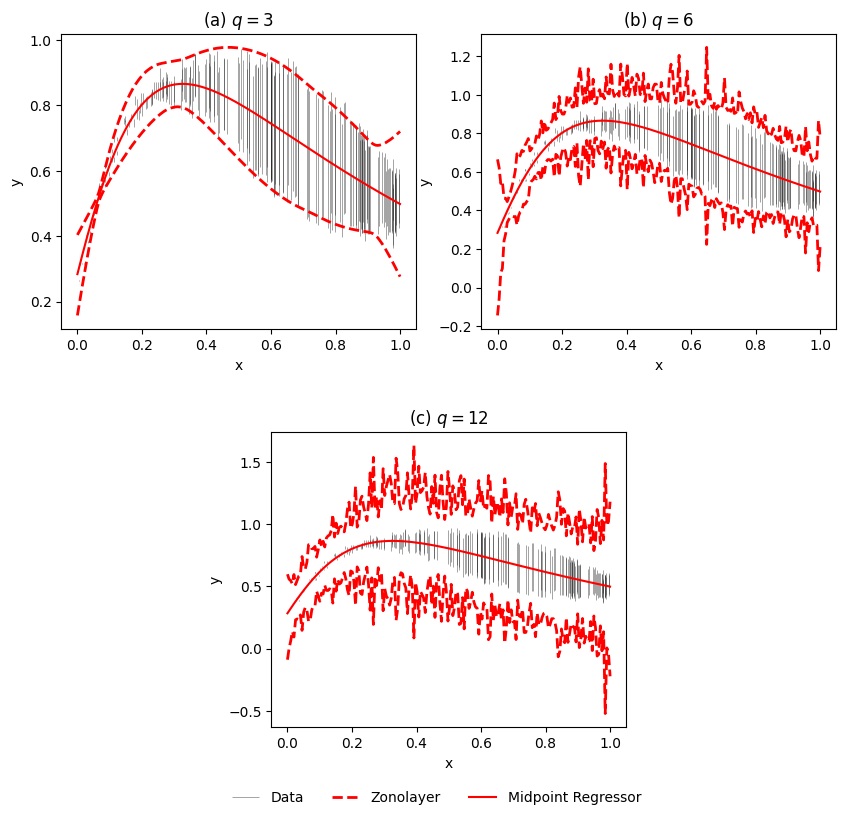

In [240]:
fig = plt.figure(figsize=(10, 9))

gs = fig.add_gridspec(
    2, 4,
    height_ratios=[1, 1],
    hspace=0.35,
    wspace=0.45
)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[1, 1:3])
]

x_plot = x_grid.squeeze()
sorted_idx = np.argsort(x_plot)
x_plot_sorted = x_plot[sorted_idx]

y_lower_data = y_lower.squeeze()
y_upper_data = y_upper.squeeze()

plot_dims = [3, 6, 12]

for ax, dim in zip(axes, plot_dims):

    result = experiments[dim]

    zonolayer = result["zonolayer"]
    pred_test = result["pred_test"]

    yl_zl = zonolayer["y_lower"]
    yu_zl = zonolayer["y_upper"]

    yl_zl_sorted = yl_zl[sorted_idx].squeeze()
    yu_zl_sorted = yu_zl[sorted_idx].squeeze()
    pred_test_sorted = pred_test[sorted_idx].squeeze()

    ax.vlines(
        x,
        y_lower_data,
        y_upper_data,
        color="black",
        alpha=0.5,
        linewidth=0.5,
        label="Data",
    )

    ax.plot(
        x_plot_sorted,
        yl_zl_sorted,
        "r--",
        lw=2,
        label="Zonolayer",
    )

    ax.plot(
        x_plot_sorted,
        yu_zl_sorted,
        "r--",
        lw=2,
    )

    ax.plot(
        x_plot_sorted,
        pred_test_sorted,
        "r-",
        lw=1.5,
        label="Midpoint Regressor",
    )

    if dim == 3:
        title = r"(a) $q = 3$"
    elif dim == 6:
        title = r"(b) $q = 6$"
    elif dim == 12:
        title = r"(c) $q = 12$"
    else:
        title = rf"$q = {dim}$"

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.savefig(
    "ArtificialDataset_Collinear.pdf",
    bbox_inches="tight"
)

plt.show()


### Multivariate Example


In [241]:
def build_numpy_feature_extractor(model):
    layer_ops = []

    for module in model.feature_extractor:
        if isinstance(module, nn.Linear):
            W = module.weight.detach().cpu().numpy()
            b = module.bias.detach().cpu().numpy()
            layer_ops.append(("linear", W, b))
        elif isinstance(module, nn.Tanh):
            layer_ops.append(("tanh", None, None))
        elif isinstance(module, nn.ReLU):
            layer_ops.append(("relu", None, None))
        elif isinstance(module, nn.Sigmoid):
            layer_ops.append(("sigmoid", None, None))
        else:
            raise NotImplementedError(
                f"No NumPy equivalent registered for layer type {type(module)}"
            )

    Wr = model.regressor.weight.detach().cpu().numpy()
    br = model.regressor.bias.detach().cpu().numpy()

    def extract(x):
        x = np.asarray(x, dtype=np.float32)
        for kind, W, b in layer_ops:
            if kind == "linear":
                x = x @ W.T + b
            elif kind == "tanh":
                x = np.tanh(x)
            elif kind == "relu":
                x = np.maximum(x, 0)
        features = x
        preds = (features @ Wr.T + br).flatten()
        return preds, features

    return extract


def intervalise_airq(y):
    y = np.asarray(y).reshape(-1)
    delta = np.abs(np.random.normal(loc=2.0, scale=1.0, size=len(y)))
    b = np.random.uniform(low=-1.0, high=1.0, size=len(y))
    m = y + b * delta

    return pd.DataFrame({
        "y": y,
        "y_lower": m - delta,
        "y_upper": m + delta
    })



auto_mpg = fetch_ucirepo(id=9)
X = auto_mpg.data.features
y_all = auto_mpg.data.targets

# Combine features and target
df = pd.concat([X, y_all], axis=1)

print(auto_mpg.metadata)
print(auto_mpg.variables)
# Auto MPG contains missing horsepower values
df = df.dropna()
feature_cols = [
    "displacement",
    "cylinders",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

target_col = "mpg"

scaler = StandardScaler()

X_norm = pd.DataFrame(
    scaler.fit_transform(df[feature_cols]),
    columns=feature_cols,
    index=df.index
)

y = df[target_col].values

interval_df = intervalise_airq(y)

# Keep the same index as df
interval_df.index = df.index

full_df = pd.concat([X_norm, interval_df], axis=1)
y_min = full_df["y_lower"].min()
y_max = full_df["y_upper"].max()

full_df["y_lower_norm"] = (
    (full_df["y_lower"] - y_min)
    / (y_max - y_min)
)

full_df["y_upper_norm"] = (
    (full_df["y_upper"] - y_min)
    / (y_max - y_min)
)

train_df, test_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=42
)


X_train = train_df[feature_cols].values
X_test = test_df[feature_cols].values

y_low_tr = train_df["y_lower_norm"].values
y_up_tr = train_df["y_upper_norm"].values

y_low_te = test_df["y_lower_norm"].values
y_up_te = test_df["y_upper_norm"].values


print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_low_tr:", y_low_tr.shape)
print("y_up_tr:", y_up_tr.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_low_te:", y_low_te.shape)
print("y_up_te:", y_up_te.shape)


class CentreNet(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=12, zono_dim=3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, zono_dim)
        )

        self.regressor = nn.Linear(zono_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)

        if return_features:
            return out, features

        return out


x_t = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_lb_t = torch.tensor(
    y_low_tr,
    dtype=torch.float32
)

y_ub_t = torch.tensor(
    y_up_tr,
    dtype=torch.float32
)

def train_centre(x_t, y_lb_t, y_ub_t, zono_dim, epochs=6000, lr=0.001, print_every=50):
    y_mid = ((y_lb_t + y_ub_t) / 2).reshape(-1, 1)

    centre_net = CentreNet(input_dim=x_t.shape[1], zono_dim=zono_dim)
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        pred = centre_net(x_t)
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch + 1}: MSE = {loss.item():.6f}")
    return centre_net

def run_zonolayer_experiment(x_train, y_low_train, y_up_train, x_test, y_low_test, y_up_test, zono_dim, epochs=6000, lr=0.001, print_every=50):
    print(f"\n=== zono_dim = {zono_dim} ===")

    x_train_t = torch.tensor(x_train, dtype=torch.float32)
    y_low_train_t = torch.tensor(y_low_train, dtype=torch.float32)
    y_up_train_t = torch.tensor(y_up_train, dtype=torch.float32)
    x_test_t = torch.tensor(x_test, dtype=torch.float32)

    centre_net = train_centre(x_train_t, y_low_train_t, y_up_train_t, zono_dim=zono_dim, epochs=epochs, lr=lr, print_every=print_every)
    centre_net_np = build_numpy_feature_extractor(centre_net)
    pred_train, latent_train = centre_net_np(x_train)


    zonolayer_fit = fit_zonolayer(latent_train, y_low_train, y_up_train)
    pred_test, latent_test = centre_net_np(x_test)
    zonolayer = predict_zonolayer(zonolayer_fit, latent_test)

    collinearity = check_collinearity(latent_train, name=f"Zonolayer (Dimension {zono_dim})")

    return {
        "zono_dim": zono_dim,
        "centre_net": centre_net,
        "centre_net_np": centre_net_np,
        "pred_train": pred_train,
        "latent_train": latent_train,
        "zonolayer_fit": zonolayer_fit,
        "pred_test": pred_test,
        "latent_test": latent_test,
        "zonolayer": zonolayer,
        "collinearity": collinearity,
    }

zono_dims = [3, 12, 24]
results = {}

for dim in zono_dims:
    results[dim] = run_zonolayer_experiment(x_train=X_train, y_low_train=y_low_tr, y_up_train=y_up_tr, x_test=X_test, y_low_test=y_low_te, y_up_test=y_up_te, zono_dim=dim, epochs=6000, lr=0.001, print_every=50)

{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

/tmp/ipykernel_43533/2950293503.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


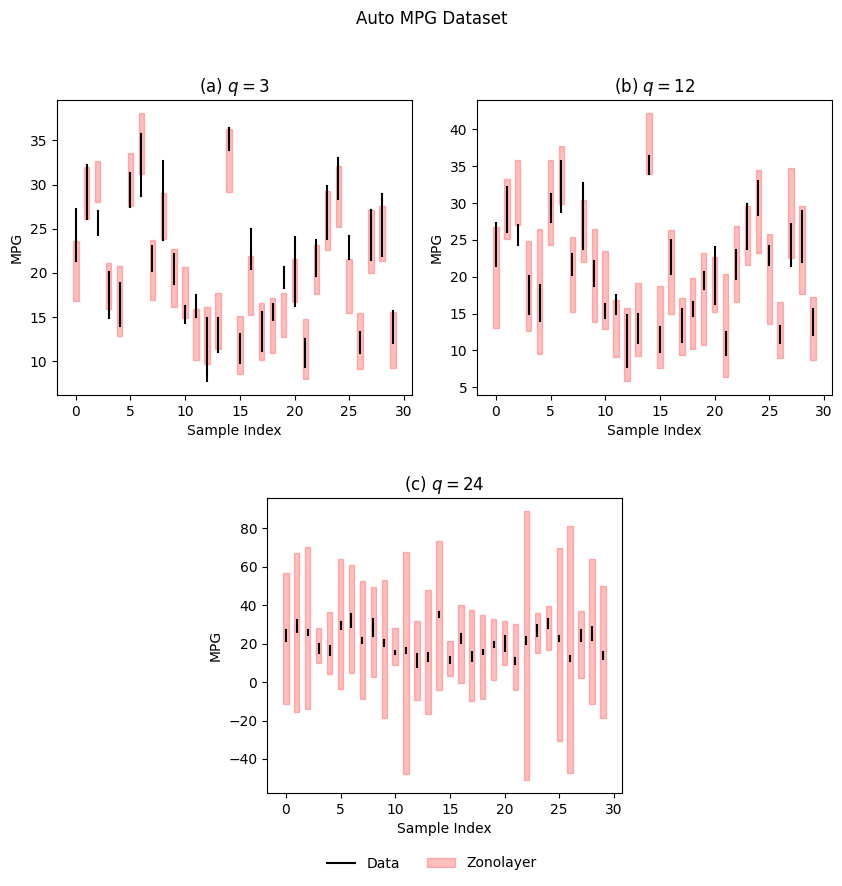

In [242]:
zono_dims = [3, 12, 24]
n_plot = 30
idx = np.sort(np.random.choice(len(X_test), n_plot, replace=False))

fig = plt.figure(figsize=(10, 9))

gs = fig.add_gridspec(
    2, 4,
    height_ratios=[1, 1],
    hspace=0.35,
    wspace=0.45
)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[1, 1:3])
]

width = 0.25

for ax, dim in zip(axes, zono_dims):
    result = results[dim]
    zonolayer = result["zonolayer"]

    yl_zl = (
        zonolayer["y_lower"] * (y_max - y_min) + y_min
    )

    yu_zl = (
        zonolayer["y_upper"] * (y_max - y_min) + y_min
    )

    y_low_te_denorm = (
        y_low_te * (y_max - y_min) + y_min
    )

    y_up_te_denorm = (
        y_up_te * (y_max - y_min) + y_min
    )

    for i, val in enumerate(idx):
        ax.plot(
            [i, i],
            [
                y_low_te_denorm[val],
                y_up_te_denorm[val]
            ],
            color="black",
            lw=1.5,
            zorder=3,
            label="Data" if i == 0 else ""
        )

        ax.fill_between(
            [i - width, i + width],
            yl_zl[val],
            yu_zl[val],
            color="red",
            alpha=0.25,
            label="Zonolayer" if i == 0 else ""
        )

    if dim == 3:
        title = r"(a) $q = 3$"
    elif dim == 12:
        title = r"(b) $q = 12$"
    elif dim == 24:
        title = r"(c) $q = 24$"
    else:
        title = rf"$q = {dim}$"

    ax.set_title(title)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("MPG")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    frameon=False
)

plt.suptitle(
    "Auto MPG Dataset",
    y=0.98
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.savefig(
    "AutoMPG_Zonolayer_Colinear.pdf",
    bbox_inches="tight"
)

plt.show()
